**Upload Dataset to Colab**

**Load the Dataset**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving mhqa.csv to mhqa.csv
Saving mhqa-b.csv to mhqa-b.csv


In [ ]:
import os

os.listdir()

['.config', 'mhqa-b.csv', 'mhqa.csv', 'sample_data']

In [ ]:
import pandas as pd

# Load CSV files
df1 = pd.read_csv("mhqa.csv")
df2 = pd.read_csv("mhqa-b.csv")

# Combine both datasets
df = pd.concat([df1, df2], ignore_index=True)

# Display first rows
print("Total samples in df1 :", df1.shape)
print("Total samples in df2 :", df2.shape)
df.head()

Total samples in df1 : (2475, 10)
Total samples in df2 : (56142, 11)


,id,topic,type,question,option1,option2,option3,option4,correct_option,correct_option_number,valid_question,correct_answer
0,28615767,Depression,Diagnostic,Which subgroup reported lower perceived social...,Recurrent depressive disorder patients,Anxiety disorder patients,Healthy individuals,First-episode depression patients,Recurrent depressive disorder patients,1.0,NaN,NaN
1,17291595,Obsessive/Compulsive Disorders,Factoid,Which group of patients exhibited lower levels...,Healthy controls,Those with social anxiety disorder,Schizophrenic patients without obsessive-compu...,Patients with obsessive-compulsive disorder,Patients with obsessive-compulsive disorder,4.0,NaN,NaN
2,38514191,Obsessive/Compulsive Disorders,Prognostic,How does the overexpression of the Slc1a1 gene...,Decreases hyperactivity,Diminishes nerve response,Reduces locomotion,Increases stereotypy,Increases stereotypy,4.0,NaN,NaN
3,12787851,Obsessive/Compulsive Disorders,Preventive,What treatment was shown to gradually decrease...,Behavioral modification training,Cognitive-behavioral therapy,Risperidone,Fluoxetine,Fluoxetine,4.0,NaN,NaN
4,24480417,Obsessive/Compulsive Disorders,Preventive,How does maternal obsessive-compulsive disorde...,By reducing maternal anxiety symptoms,By decreasing fetal TNF-Î± levels,By improving maternal mental health,By increasing fetal neuroinflammation,By increasing fetal neuroinflammation,4.0,NaN,NaN


**VERIFY DATA**

In [ ]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)
df.info()

Shape: (58617, 12)

Columns: Index(['id', 'topic', 'type', 'question', 'option1', 'option2', 'option3',
       'option4', 'correct_option', 'correct_option_number', 'valid_question',
       'correct_answer'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58617 entries, 0 to 58616
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     58617 non-null  int64  
 1   topic                  58617 non-null  object 
 2   type                   58617 non-null  object 
 3   question               58617 non-null  object 
 4   option1                58617 non-null  object 
 5   option2                58617 non-null  object 
 6   option3                58617 non-null  object 
 7   option4                58617 non-null  object 
 8   correct_option         2475 non-null   object 
 9   correct_option_number  58617 non-null  float64
 10  valid_question         56142 no

**Select Required Columns**

In [ ]:
# Select only required columns
df = df[['question', 'topic']]

# Rename for clarity (optional but professional)
df.rename(columns={'topic': 'domain'}, inplace=True)

# Check
df.head()

,question,domain
0,Which subgroup reported lower perceived social...,Depression
1,Which group of patients exhibited lower levels...,Obsessive/Compulsive Disorders
2,How does the overexpression of the Slc1a1 gene...,Obsessive/Compulsive Disorders
3,What treatment was shown to gradually decrease...,Obsessive/Compulsive Disorders
4,How does maternal obsessive-compulsive disorde...,Obsessive/Compulsive Disorders


**HANDLE MISSING / INVALID DATA**

In [ ]:
df.dropna(subset=['question', 'domain'], inplace=True)

df.shape

(58617, 2)

**DOMAIN** **DISTRIBUTION**

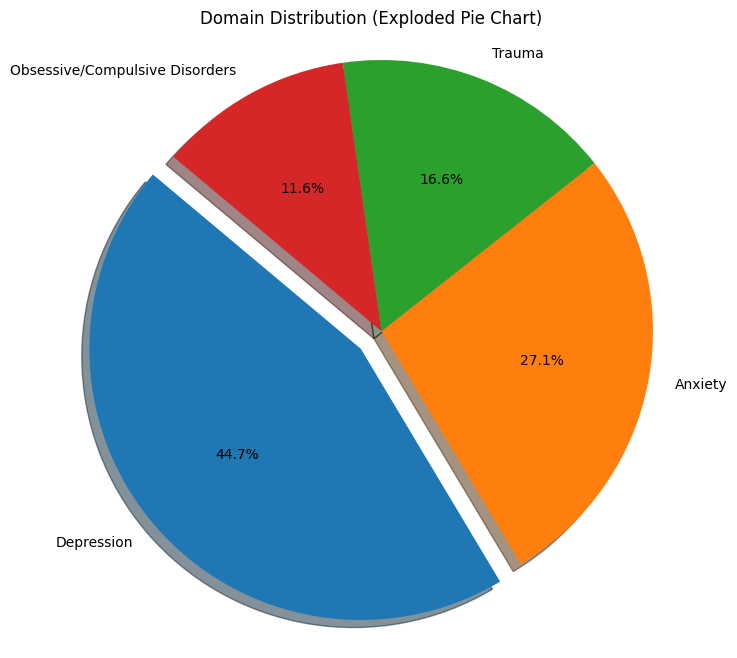

In [ ]:
import matplotlib.pyplot as plt

# Count values
domain_counts = df['domain'].value_counts()

# Create explode list (highlight all slices slightly)
explode = [0.05] * len(domain_counts)

# Plot pie chart
plt.figure(figsize=(8,8))
plt.pie(domain_counts,
        labels=domain_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        explode = [0.1 if i == 0 else 0 for i in range(len(domain_counts))],
        shadow=True)

plt.title("Domain Distribution (Exploded Pie Chart)")
plt.axis('equal')
plt.show()

**TEXT CLEANING FUNCTION**

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()  # lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # remove symbols
    words = text.split()

    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

# Apply cleaning
df['clean_text'] = df['question'].apply(clean_text)

df[['question', 'clean_text']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,question,clean_text
0,Which subgroup reported lower perceived social...,subgroup reported lower perceived social suppo...
1,Which group of patients exhibited lower levels...,group patient exhibited lower level whole bloo...
2,How does the overexpression of the Slc1a1 gene...,overexpression slc gene forebrain neuron poten...
3,What treatment was shown to gradually decrease...,treatment shown gradually decrease stereotypic...
4,How does maternal obsessive-compulsive disorde...,maternal obsessive compulsive disorder pregnan...


**TOP WORDS ANALYSIS**

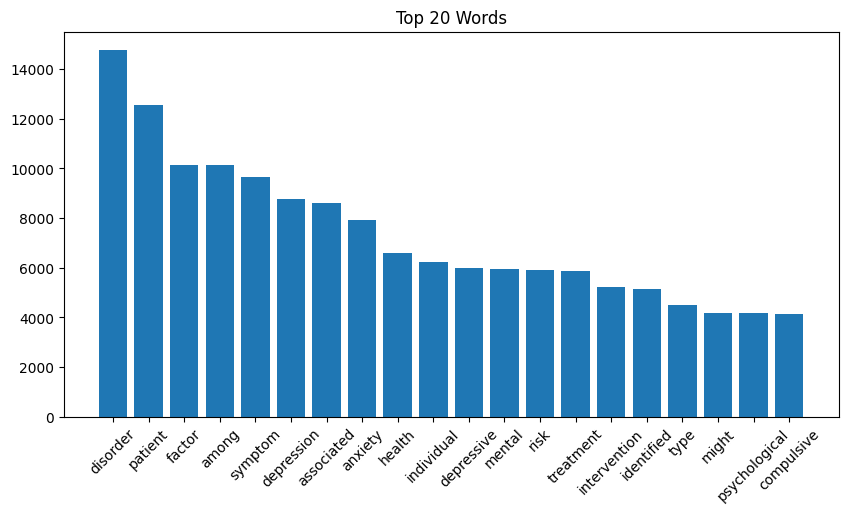

In [ ]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()
word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Words")
plt.show()

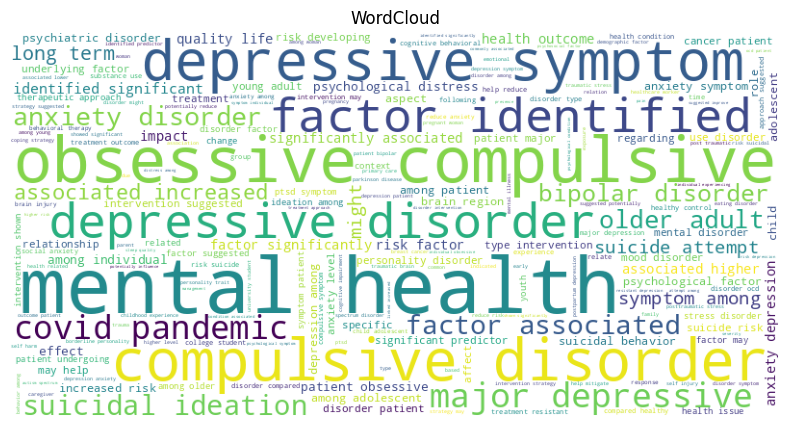

In [ ]:
!pip install wordcloud

from wordcloud import WordCloud

text = " ".join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("WordCloud")
plt.show()

xxxxxxxxxxxxxxxxxxx

**FEATURE ENGINEERING (ML MODELS)**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text']).toarray()
y = df['domain']

**TRAIN–TEST SPLIT**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (46893, 5000)
Test shape: (11724, 5000)


**MACHINE LEARNING MODELS**

**TRAIN ALL ML MODELS**

In [ ]:
# ===== ML SECTION 2: TRAIN MODELS =====

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

**FULL METRICS**

In [ ]:
# ===== ML SECTION: CLEAN METRICS FORMAT =====

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate_model(y_true, y_pred, model_name):

    print("\n" + "="*60)
    print(f"🔷 MODEL: {model_name}")
    print("="*60)

    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"F1 Score  : {f1_score(y_true, y_pred, average='weighted'):.4f}")

    print("\n" + "-"*60)
    print("📊 Classification Report:")
    print("-"*60)
    print(classification_report(y_true, y_pred))

    print("-"*60)
    print("📉 Confusion Matrix:")
    print("-"*60)
    print(confusion_matrix(y_true, y_pred))

    print("="*60 + "\n")

In [ ]:
# ===== APPLY METRICS =====

evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_nb, "Naive Bayes")
evaluate_model(y_test, y_pred_rf, "Random Forest")


🔷 MODEL: Logistic Regression
Accuracy  : 0.8005
Precision : 0.8013
Recall    : 0.8005
F1 Score  : 0.7997

------------------------------------------------------------
📊 Classification Report:
------------------------------------------------------------
                                precision    recall  f1-score   support

                       Anxiety       0.76      0.76      0.76      3192
                    Depression       0.81      0.86      0.83      5283
Obsessive/Compulsive Disorders       0.94      0.84      0.89      1334
                        Trauma       0.76      0.68      0.72      1915

                      accuracy                           0.80     11724
                     macro avg       0.82      0.78      0.80     11724
                  weighted avg       0.80      0.80      0.80     11724

------------------------------------------------------------
📉 Confusion Matrix:
------------------------------------------------------------
[[2411  593   34  154]
 [

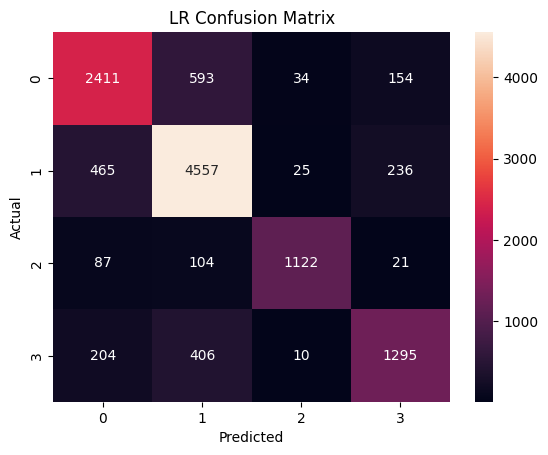

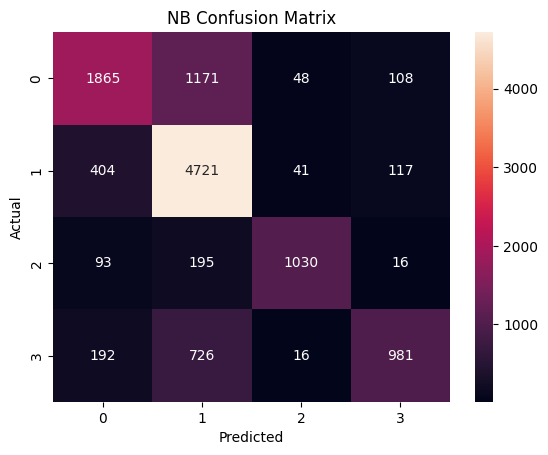

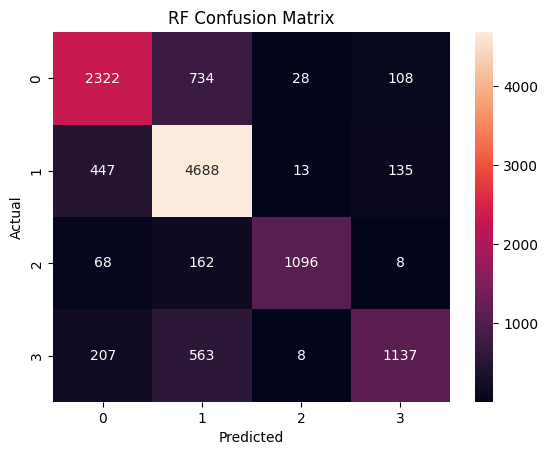

In [ ]:
# ===== ML SECTION 5: HEATMAPS =====

import seaborn as sns
import matplotlib.pyplot as plt

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_test, y_pred_lr, "LR Confusion Matrix")
plot_cm(y_test, y_pred_nb, "NB Confusion Matrix")
plot_cm(y_test, y_pred_rf, "RF Confusion Matrix")

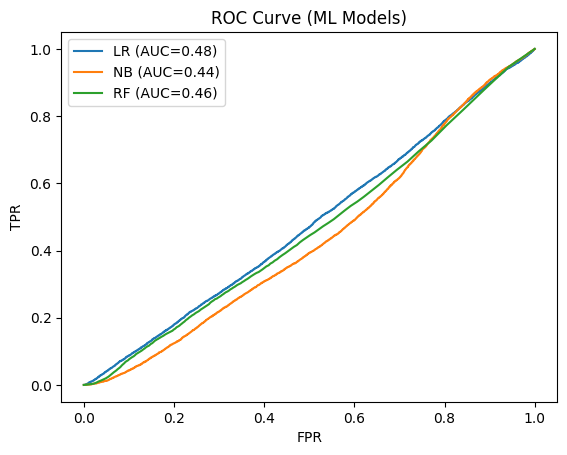

In [ ]:
# ===== ML SECTION 6: ROC CURVE =====

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

classes = list(set(y))

y_test_bin = label_binarize(y_test, classes=classes)

def plot_roc(model, X_test, name):
    y_prob = model.predict_proba(X_test)

    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.figure()

plot_roc(lr, X_test, "LR")
plot_roc(nb, X_test, "NB")
plot_roc(rf, X_test, "RF")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (ML Models)")
plt.legend()
plt.show()

In [ ]:
# ===== ML SECTION 7: TABLE =====

import pandas as pd

results_ml = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, average='weighted'),
        precision_score(y_test, y_pred_nb, average='weighted'),
        precision_score(y_test, y_pred_rf, average='weighted')
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, average='weighted'),
        recall_score(y_test, y_pred_nb, average='weighted'),
        recall_score(y_test, y_pred_rf, average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_nb, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted')
    ]
})

print("\n🔹 ML MODELS COMPARISON:\n")
print(results_ml)


🔹 ML MODELS COMPARISON:

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.800495   0.801251  0.800495  0.799708
1          Naive Bayes  0.733282   0.745446  0.733282  0.725577
2        Random Forest  0.788383   0.794062  0.788383  0.785458


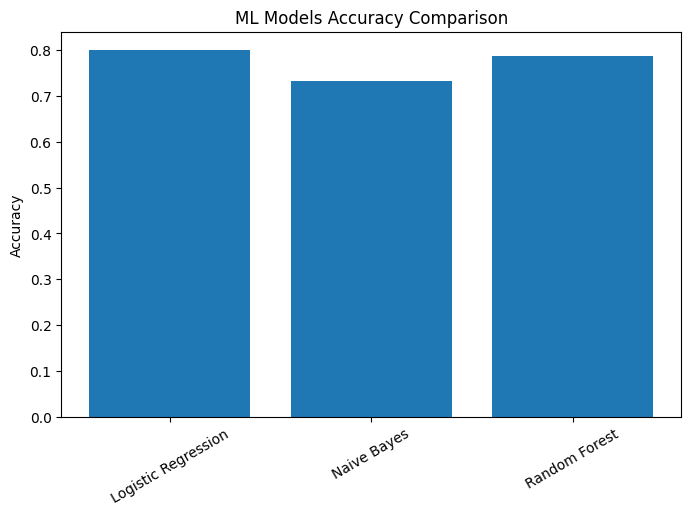

In [ ]:
# ===== ML SECTION 8: GRAPH =====

plt.figure(figsize=(8,5))
plt.bar(results_ml['Model'], results_ml['Accuracy'])
plt.xticks(rotation=30)
plt.title("ML Models Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

**DEEP LEARNING (LSTM + GRU)**

**TOKENIZATION + PADDING**

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 10000
max_length = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])
X_pad = pad_sequences(sequences, maxlen=max_length, padding='post')

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(df['domain'])

from sklearn.model_selection import train_test_split
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_pad, y_encoded, test_size=0.2, random_state=42
)

**LSTM MODEL**

In [ ]:
# ===== DL MODEL 1: IMPROVED LSTM =====

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=2)

model_lstm = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    LSTM(128),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(len(set(y_encoded)), activation='softmax')
])

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_lstm = model_lstm.fit(
    X_train_dl, y_train_dl,
    epochs=10,
    validation_data=(X_test_dl, y_test_dl),
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.4456 - loss: 1.2678 - val_accuracy: 0.4506 - val_loss: 1.2568
Epoch 2/10
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.4459 - loss: 1.2654 - val_accuracy: 0.4506 - val_loss: 1.2576
Epoch 3/10
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.4459 - loss: 1.2650 - val_accuracy: 0.4506 - val_loss: 1.2568
Epoch 4/10
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.4459 - loss: 1.2645 - val_accuracy: 0.4506 - val_loss: 1.2599
Epoch 5/10
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.4459 - loss: 1.2643 - val_accuracy: 0.4506 - val_loss: 1.2570


**GRU MODEL**

In [ ]:
# ===== DL MODEL 2: IMPROVED GRU =====

from tensorflow.keras.layers import GRU

model_gru = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    GRU(128),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(len(set(y_encoded)), activation='softmax')
])

model_gru.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_gru = model_gru.fit(
    X_train_dl, y_train_dl,
    epochs=10,
    validation_data=(X_test_dl, y_test_dl),
    callbacks=[early_stop]
)

Epoch 1/10
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.4458 - loss: 1.2677 - val_accuracy: 0.4506 - val_loss: 1.2575
Epoch 2/10
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.4459 - loss: 1.2652 - val_accuracy: 0.4506 - val_loss: 1.2567
Epoch 3/10
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.4459 - loss: 1.2647 - val_accuracy: 0.4506 - val_loss: 1.2569
Epoch 4/10
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.4459 - loss: 1.2646 - val_accuracy: 0.4506 - val_loss: 1.2577


In [ ]:
# ===== DL METRICS FUNCTION =====

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np

def evaluate_dl(y_true, y_pred, model_name):

    print("\n" + "="*60)
    print(f"🔷 MODEL: {model_name}")
    print("="*60)

    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"F1 Score  : {f1_score(y_true, y_pred, average='weighted'):.4f}")

    print("\n" + "-"*60)
    print("📊 Classification Report:")
    print("-"*60)
    print(classification_report(y_true, y_pred))

    print("-"*60)
    print("📉 Confusion Matrix:")
    print("-"*60)
    print(confusion_matrix(y_true, y_pred))

    print("="*60 + "\n")

In [ ]:
# ===== DL PREDICTIONS =====

y_pred_lstm = np.argmax(model_lstm.predict(X_test_dl), axis=1)
y_pred_gru = np.argmax(model_gru.predict(X_test_dl), axis=1)

evaluate_dl(y_test_dl, y_pred_lstm, "LSTM")
evaluate_dl(y_test_dl, y_pred_gru, "GRU")

367/367 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

🔷 MODEL: LSTM
Accuracy  : 0.4506
Precision : 0.2031
Recall    : 0.4506
F1 Score  : 0.2800

------------------------------------------------------------
📊 Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3192
           1       0.45      1.00      0.62      5283
           2       0.00      0.00      0.00      1334
           3       0.00      0.00      0.00      1915

    accuracy                           0.45     11724
   macro avg       0.11      0.25      0.16     11724
weighted avg       0.20      0.45      0.28     11724

------------------------------------------------------------
📉 Confusion Matrix:
------------------------------------------------------------
[[   0 3192    0    0]
 [   0 5283    0    0]
 [   0 1334    0    0]
 [   0 1915    0    0]]


🔷 MODEL

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

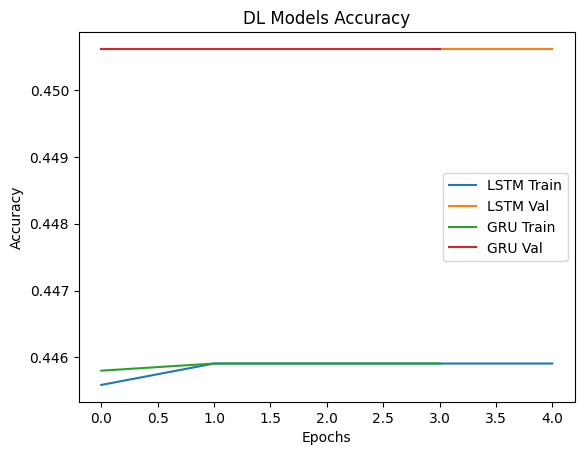

In [ ]:
# ===== TRAINING CURVES =====

import matplotlib.pyplot as plt

plt.figure()
plt.plot(history_lstm.history['accuracy'], label='LSTM Train')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val')

plt.plot(history_gru.history['accuracy'], label='GRU Train')
plt.plot(history_gru.history['val_accuracy'], label='GRU Val')

plt.title("DL Models Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

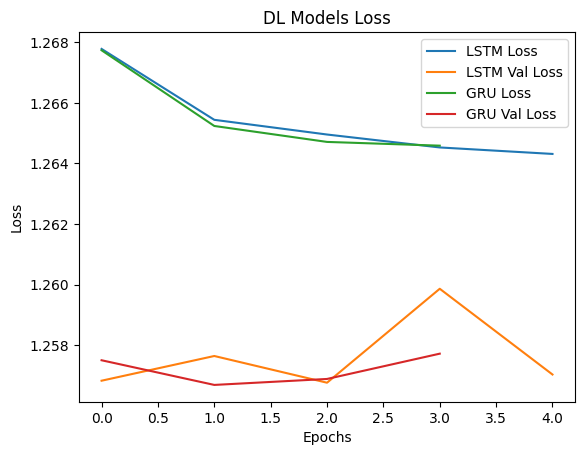

In [ ]:
plt.figure()
plt.plot(history_lstm.history['loss'], label='LSTM Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val Loss')

plt.plot(history_gru.history['loss'], label='GRU Loss')
plt.plot(history_gru.history['val_loss'], label='GRU Val Loss')

plt.title("DL Models Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

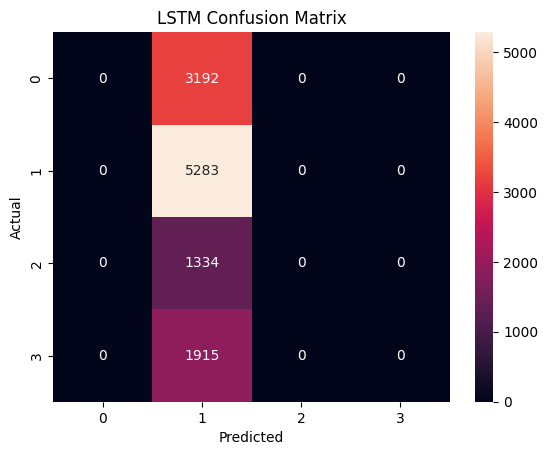

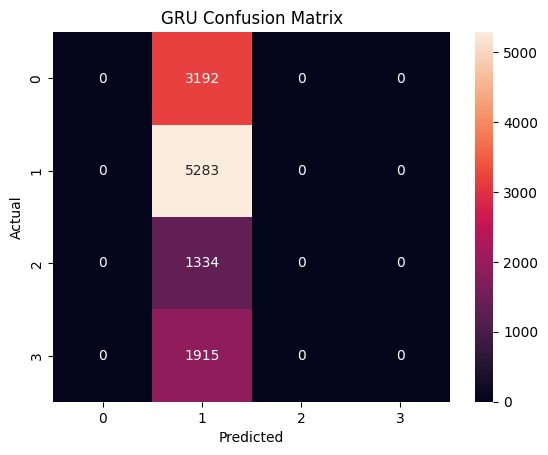

In [ ]:
import seaborn as sns

def plot_cm_dl(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm_dl(y_test_dl, y_pred_lstm, "LSTM Confusion Matrix")
plot_cm_dl(y_test_dl, y_pred_gru, "GRU Confusion Matrix")

In [ ]:
import pandas as pd

results_dl = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "Accuracy": [
        accuracy_score(y_test_dl, y_pred_lstm),
        accuracy_score(y_test_dl, y_pred_gru)
    ],
    "Precision": [
        precision_score(y_test_dl, y_pred_lstm, average='weighted'),
        precision_score(y_test_dl, y_pred_gru, average='weighted')
    ],
    "Recall": [
        recall_score(y_test_dl, y_pred_lstm, average='weighted'),
        recall_score(y_test_dl, y_pred_gru, average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test_dl, y_pred_lstm, average='weighted'),
        f1_score(y_test_dl, y_pred_gru, average='weighted')
    ]
})

print("\n🔹 DL MODELS COMPARISON:\n")
print(results_dl)


🔹 DL MODELS COMPARISON:

  Model  Accuracy  Precision    Recall  F1 Score
0  LSTM  0.450614   0.203053  0.450614  0.279955
1   GRU  0.450614   0.203053  0.450614  0.279955


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


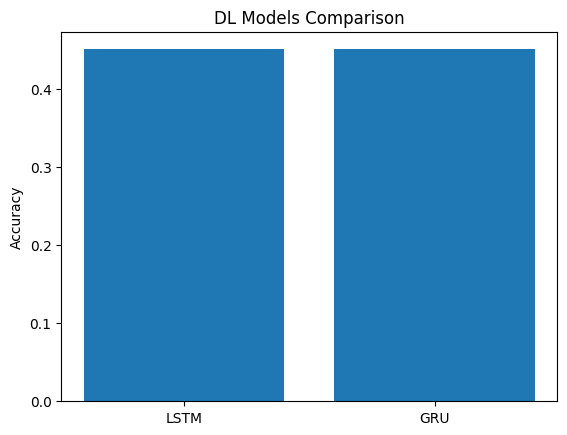

In [ ]:
plt.figure()
plt.bar(results_dl['Model'], results_dl['Accuracy'])
plt.title("DL Models Comparison")
plt.ylabel("Accuracy")
plt.show()

xxxxxxxxxxxxxxxxxxx

**TRANSFORMER IMPLEMENTATION**

In [ ]:
# # ===== TRANSFORMERS COMMON SETUP =====

# !pip install transformers datasets -q

# import torch
# import numpy as np
# from datasets import Dataset
# from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# from transformers import Trainer, TrainingArguments

In [ ]:
# # Convert labels

# labels = df['domain'].unique().tolist()
# label2id = {label: i for i, label in enumerate(labels)}
# id2label = {i: label for label, i in label2id.items()}

# df['label'] = df['domain'].map(label2id)

# print("Label Mapping:", label2id)

Label Mapping: {'Depression': 0, 'Obsessive/Compulsive Disorders': 1, 'Anxiety': 2, 'Trauma': 3}


In [ ]:
# from sklearn.model_selection import train_test_split

# train_texts, test_texts, train_labels, test_labels = train_test_split(
#     df['clean_text'].tolist(),
#     df['label'].tolist(),
#     test_size=0.2,
#     random_state=42
# )

In [ ]:
# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     preds = np.argmax(logits, axis=1)

#     precision, recall, f1, _ = precision_recall_fscore_support(
#         labels, preds, average='weighted'
#     )
#     acc = accuracy_score(labels, preds)

#     return {
#         "accuracy": acc,
#         "f1": f1,
#         "precision": precision,
#         "recall": recall
#     }

In [ ]:
# training_args = TrainingArguments(
#     output_dir='./results',
#     num_train_epochs=2,
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=8,
#     do_train=True,
#     do_eval=True,
#     logging_dir='./logs',
#     save_strategy="no"
# )

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.




**BERT**


In [ ]:
# from transformers import BertTokenizer, BertForSequenceClassification

In [ ]:
# bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# train_encodings = bert_tokenizer(
#     train_texts,
#     truncation=True,
#     padding=True,
#     max_length=128
# )

# test_encodings = bert_tokenizer(
#     test_texts,
#     truncation=True,
#     padding=True,
#     max_length=128
# )

In [ ]:
# train_dataset = Dataset.from_dict({
#     'input_ids': train_encodings['input_ids'],
#     'attention_mask': train_encodings['attention_mask'],
#     'labels': train_labels
# })

# test_dataset = Dataset.from_dict({
#     'input_ids': test_encodings['input_ids'],
#     'attention_mask': test_encodings['attention_mask'],
#     'labels': test_labels
# })

In [ ]:
# bert_model = BertForSequenceClassification.from_pretrained(
#     'bert-base-uncased',
#     num_labels=len(labels)
# )

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# print("\n" + "="*60)
# print("🚀 TRAINING BERT")
# print("="*60)

# bert_trainer = Trainer(
#     model=bert_model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=test_dataset,
#     compute_metrics=compute_metrics
# )

# bert_trainer.train()

# print("\n" + "-"*60)
# print("🔷 BERT EVALUATION")
# print("-"*60)

# bert_results = bert_trainer.evaluate()

# for k, v in bert_results.items():
#     print(f"{k.upper()} : {v:.4f}")

# print("="*60)


🚀 TRAINING BERT


Step,Training Loss
500,0.736692
1000,0.628584
1500,0.593514
2000,0.599457
2500,0.555276
3000,0.575261
3500,0.548430
4000,0.536443
4500,0.551012
5000,0.538241


Step,Training Loss
500,0.736692
1000,0.628584
1500,0.593514
2000,0.599457
2500,0.555276
3000,0.575261
3500,0.548430
4000,0.536443
4500,0.551012
5000,0.538241



------------------------------------------------------------
🔷 BERT EVALUATION
------------------------------------------------------------


EVAL_LOSS : 0.5273
EVAL_ACCURACY : 0.8101
EVAL_F1 : 0.8098
EVAL_PRECISION : 0.8100
EVAL_RECALL : 0.8101
EVAL_RUNTIME : 29.7754
EVAL_SAMPLES_PER_SECOND : 393.7480
EVAL_STEPS_PER_SECOND : 49.2350
EPOCH : 2.0000


**DISTILBERT**

In [ ]:
# from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

In [ ]:
# distil_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# train_encodings = distil_tokenizer(
#     train_texts,
#     truncation=True,
#     padding=True,
#     max_length=128
# )

# test_encodings = distil_tokenizer(
#     test_texts,
#     truncation=True,
#     padding=True,
#     max_length=128
# )

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# train_dataset = Dataset.from_dict({
#     'input_ids': train_encodings['input_ids'],
#     'attention_mask': train_encodings['attention_mask'],
#     'labels': train_labels
# })

# test_dataset = Dataset.from_dict({
#     'input_ids': test_encodings['input_ids'],
#     'attention_mask': test_encodings['attention_mask'],
#     'labels': test_labels
# })

In [ ]:
# distil_model = DistilBertForSequenceClassification.from_pretrained(
#     'distilbert-base-uncased',
#     num_labels=len(labels)
# )

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# print("\n" + "="*60)
# print("🚀 TRAINING DISTILBERT")
# print("="*60)

# distil_trainer = Trainer(
#     model=distil_model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=test_dataset,
#     compute_metrics=compute_metrics
# )

# distil_trainer.train()

# print("\n" + "-"*60)
# print("🔷 DISTILBERT EVALUATION")
# print("-"*60)

# distil_results = distil_trainer.evaluate()

# for k, v in distil_results.items():
#     print(f"{k.upper()} : {v:.4f}")

# print("="*60)


🚀 TRAINING DISTILBERT


Step,Training Loss
500,0.730802
1000,0.626107
1500,0.581477
2000,0.596939
2500,0.543992
3000,0.554457
3500,0.535398
4000,0.523231
4500,0.537818
5000,0.529156



------------------------------------------------------------
🔷 DISTILBERT EVALUATION
------------------------------------------------------------


EVAL_LOSS : 0.5237
EVAL_ACCURACY : 0.8097
EVAL_F1 : 0.8099
EVAL_PRECISION : 0.8103
EVAL_RECALL : 0.8097
EVAL_RUNTIME : 15.9305
EVAL_SAMPLES_PER_SECOND : 735.9490
EVAL_STEPS_PER_SECOND : 92.0250
EPOCH : 2.0000


**ROBERTA**

In [ ]:
# from transformers import RobertaTokenizer, RobertaForSequenceClassification

In [ ]:
# roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# train_encodings = roberta_tokenizer(
#     train_texts,
#     truncation=True,
#     padding=True,
#     max_length=128
# )

# test_encodings = roberta_tokenizer(
#     test_texts,
#     truncation=True,
#     padding=True,
#     max_length=128
# )

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# train_dataset = Dataset.from_dict({
#     'input_ids': train_encodings['input_ids'],
#     'attention_mask': train_encodings['attention_mask'],
#     'labels': train_labels
# })

# test_dataset = Dataset.from_dict({
#     'input_ids': test_encodings['input_ids'],
#     'attention_mask': test_encodings['attention_mask'],
#     'labels': test_labels
# })

In [ ]:
# roberta_model = RobertaForSequenceClassification.from_pretrained(
#     'roberta-base',
#     num_labels=len(labels)
# )

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# print("\n" + "="*60)
# print("🚀 TRAINING ROBERTA")
# print("="*60)

# roberta_trainer = Trainer(
#     model=roberta_model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=test_dataset,
#     compute_metrics=compute_metrics
# )

# roberta_trainer.train()

# print("\n" + "-"*60)
# print("🔷 ROBERTA EVALUATION")
# print("-"*60)

# roberta_results = roberta_trainer.evaluate()

# for k, v in roberta_results.items():
#     print(f"{k.upper()} : {v:.4f}")

# print("="*60)


🚀 TRAINING ROBERTA


Step,Training Loss
500,1.295991
1000,1.267192
1500,1.265124
2000,1.286967
2500,1.274754
3000,1.278995
3500,1.268039
4000,1.273528
4500,1.271515
5000,1.255037



------------------------------------------------------------
🔷 ROBERTA EVALUATION
------------------------------------------------------------


EVAL_LOSS : 1.2572
EVAL_ACCURACY : 0.4506
EVAL_F1 : 0.2800
EVAL_PRECISION : 0.2031
EVAL_RECALL : 0.4506
EVAL_RUNTIME : 24.5767
EVAL_SAMPLES_PER_SECOND : 477.0380
EVAL_STEPS_PER_SECOND : 59.6500
EPOCH : 2.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#  print("\n" + "="*60)
# print("📊 FINAL TRANSFORMER COMPARISON")
# print("="*60)

# print(f"BERT Accuracy       : {bert_results['eval_accuracy']:.4f}")
# print(f"DistilBERT Accuracy : {distil_results['eval_accuracy']:.4f}")
# print(f"RoBERTa Accuracy    : {roberta_results['eval_accuracy']:.4f}")

# print("="*60)


📊 FINAL TRANSFORMER COMPARISON
BERT Accuracy       : 0.8101
DistilBERT Accuracy : 0.8097
RoBERTa Accuracy    : 0.4506


xxxxxxxxxxxxxxx

In [ ]:
!pip install --upgrade --quiet transformers datasets
import transformers
print(transformers.__version__)  # confirm it prints 5.0.0

5.0.0


In [ ]:
!pip install --upgrade transformers datasets -q
import transformers
import torch

print("Transformers version:", transformers.__version__)
print("Torch version       :", torch.__version__)

Transformers version: 5.0.0
Torch version       : 2.10.0+cu128


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from datasets import Dataset

# Convert labels to IDs
labels = df['domain'].unique().tolist()
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}
df['label'] = df['domain'].map(label2id)
print("Label Mapping:", label2id)

# Split data
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['clean_text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42
)

Label Mapping: {'Depression': 0, 'Obsessive/Compulsive Disorders': 1, 'Anxiety': 2, 'Trauma': 3}


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted'
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_dir='./logs',
    seed=42,
    save_total_limit=2,      # Only keeps last 2 checkpoints
    report_to="none"         # Disable WandB/other logging
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
labels = df['domain'].unique().tolist()
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

df['label'] = df['domain'].map(label2id)

print("Label Mapping:", label2id)

Label Mapping: {'Depression': 0, 'Obsessive/Compulsive Disorders': 1, 'Anxiety': 2, 'Trauma': 3}


In [ ]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['clean_text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42
)

In [ ]:
from transformers import BertTokenizer, DistilBertTokenizer, RobertaTokenizer

# BERT
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
train_encodings_bert = bert_tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_encodings_bert  = bert_tokenizer(test_texts, truncation=True, padding=True, max_length=128)

# DistilBERT
distil_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
train_encodings_distil = distil_tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_encodings_distil  = distil_tokenizer(test_texts, truncation=True, padding=True, max_length=128)

# RoBERTa
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
train_encodings_roberta = roberta_tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_encodings_roberta  = roberta_tokenizer(test_texts, truncation=True, padding=True, max_length=128)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
from datasets import Dataset

# ==========================
# BERT Dataset
# ==========================
train_dataset_bert = Dataset.from_dict({
    'input_ids': train_encodings_bert['input_ids'],
    'attention_mask': train_encodings_bert['attention_mask'],
    'labels': train_labels
})

test_dataset_bert = Dataset.from_dict({
    'input_ids': test_encodings_bert['input_ids'],
    'attention_mask': test_encodings_bert['attention_mask'],
    'labels': test_labels
})

# ==========================
# DistilBERT Dataset
# ==========================
train_dataset_distil = Dataset.from_dict({
    'input_ids': train_encodings_distil['input_ids'],
    'attention_mask': train_encodings_distil['attention_mask'],
    'labels': train_labels
})

test_dataset_distil = Dataset.from_dict({
    'input_ids': test_encodings_distil['input_ids'],
    'attention_mask': test_encodings_distil['attention_mask'],
    'labels': test_labels
})

# ==========================
# RoBERTa Dataset
# ==========================
train_dataset_roberta = Dataset.from_dict({
    'input_ids': train_encodings_roberta['input_ids'],
    'attention_mask': train_encodings_roberta['attention_mask'],
    'labels': train_labels
})

test_dataset_roberta = Dataset.from_dict({
    'input_ids': test_encodings_roberta['input_ids'],
    'attention_mask': test_encodings_roberta['attention_mask'],
    'labels': test_labels
})

print("✅ Datasets prepared for BERT, DistilBERT, and RoBERTa")

✅ Datasets prepared for BERT, DistilBERT, and RoBERTa


In [ ]:
from transformers import BertForSequenceClassification, DistilBertForSequenceClassification, RobertaForSequenceClassification, Trainer

# ==========================
# 1️⃣ Initialize Models
# ==========================
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(labels)
)

distil_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(labels)
)

roberta_model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=len(labels)
)

print("✅ Models initialized")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Models initialized


In [ ]:
# ==========================
# 2️⃣ Define compute_metrics
# ==========================
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

print("✅ Metrics function ready")

✅ Metrics function ready


In [ ]:
# ==========================
# 3️⃣ TrainingArguments (compatible with Transformers 5.0.0)
# ==========================
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir='./logs',
    logging_steps=10,
    save_strategy="no"  # no saving during training
)

print("✅ TrainingArguments ready")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ TrainingArguments ready


In [ ]:
# ==========================
# 4️⃣ Trainer Setup & Training
# ==========================
from transformers import Trainer

# BERT Trainer
bert_trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset_bert,
    eval_dataset=test_dataset_bert,
    compute_metrics=compute_metrics
)

# DistilBERT Trainer
distil_trainer = Trainer(
    model=distil_model,
    args=training_args,
    train_dataset=train_dataset_distil,
    eval_dataset=test_dataset_distil,
    compute_metrics=compute_metrics
)

# RoBERTa Trainer
roberta_trainer = Trainer(
    model=roberta_model,
    args=training_args,
    train_dataset=train_dataset_roberta,
    eval_dataset=test_dataset_roberta,
    compute_metrics=compute_metrics
)

print("✅ Trainers ready")

✅ Trainers ready


In [ ]:
print("🚀 Training BERT...")
bert_trainer.train()
bert_results = bert_trainer.evaluate()

print("🚀 Training DistilBERT...")
distil_trainer.train()
distil_results = distil_trainer.evaluate()

print("🚀 Training RoBERTa...")
roberta_trainer.train()
roberta_results = roberta_trainer.evaluate()

🚀 Training BERT...


Step,Training Loss
10,1.301380
20,1.228637
30,1.267072
40,1.241462
50,1.186744
60,1.135289
70,1.142487
80,0.909481
90,0.846697
100,0.751906


🚀 Training DistilBERT...


Step,Training Loss
10,1.345493
20,1.187613
30,1.241122
40,1.140443
50,1.061009
60,0.984022
70,0.990347
80,0.776213
90,0.699216
100,0.674694


🚀 Training RoBERTa...


Step,Training Loss
10,1.355558
20,1.206328
30,1.385588
40,1.288945
50,1.269614
60,1.279303
70,1.263984
80,1.005681
90,0.994567
100,1.121687


In [ ]:
print("📊 Transformer Model Comparison")
print(f"BERT Accuracy       : {bert_results['eval_accuracy']:.4f}")
print(f"DistilBERT Accuracy : {distil_results['eval_accuracy']:.4f}")
print(f"RoBERTa Accuracy    : {roberta_results['eval_accuracy']:.4f}")

📊 Transformer Model Comparison
BERT Accuracy       : 0.8032
DistilBERT Accuracy : 0.8050
RoBERTa Accuracy    : 0.8047


**Combine all model results into one table**

In [ ]:
# ML results already in results_ml
# DL results already in results_dl
# Transformers results
results_transformers = pd.DataFrame({
    "Model": ["BERT", "DistilBERT", "RoBERTa"],
    "Accuracy": [bert_results['eval_accuracy'], distil_results['eval_accuracy'], roberta_results['eval_accuracy']],
    "Precision": [bert_results['eval_precision'], distil_results['eval_precision'], roberta_results['eval_precision']],
    "Recall": [bert_results['eval_recall'], distil_results['eval_recall'], roberta_results['eval_recall']],
    "F1 Score": [bert_results['eval_f1'], distil_results['eval_f1'], roberta_results['eval_f1']]
})

# Combine all
all_results = pd.concat([results_ml, results_dl, results_transformers], ignore_index=True)
print(all_results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.800495   0.801251  0.800495  0.799708
1          Naive Bayes  0.733282   0.745446  0.733282  0.725577
2        Random Forest  0.788383   0.794062  0.788383  0.785458
3                 LSTM  0.450614   0.203053  0.450614  0.279955
4                  GRU  0.450614   0.203053  0.450614  0.279955
5                 BERT  0.803224   0.802475  0.803224  0.802587
6           DistilBERT  0.805015   0.804493  0.805015  0.804688
7              RoBERTa  0.804674   0.804197  0.804674  0.804288


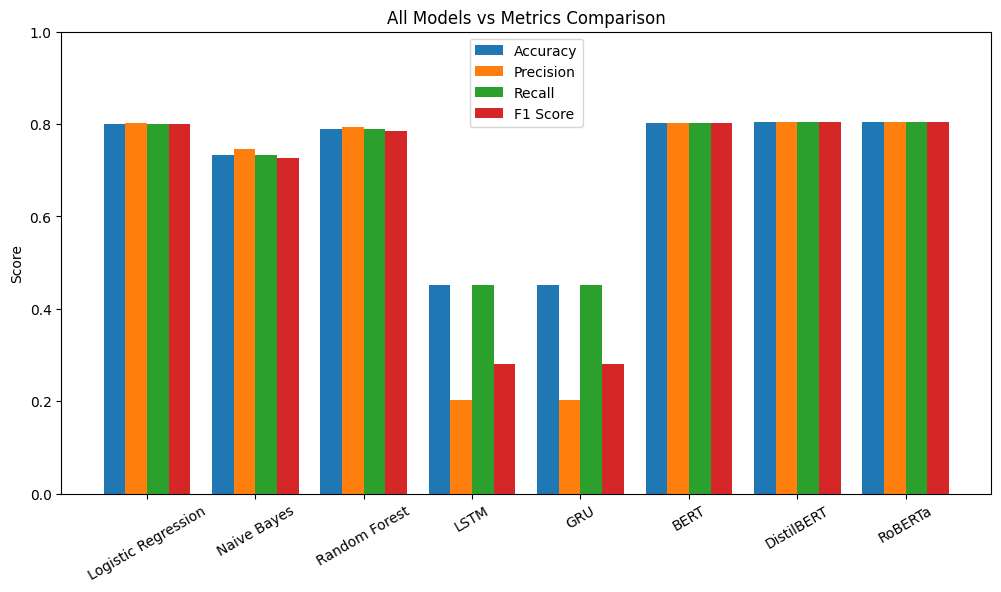

In [ ]:
plt.figure(figsize=(12,6))
x = np.arange(len(all_results))
width = 0.2

plt.bar(x - width*1.5, all_results['Accuracy'], width, label='Accuracy')
plt.bar(x - width/2, all_results['Precision'], width, label='Precision')
plt.bar(x + width/2, all_results['Recall'], width, label='Recall')
plt.bar(x + width*1.5, all_results['F1 Score'], width, label='F1 Score')

plt.xticks(x, all_results['Model'], rotation=30)
plt.title("All Models vs Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend()
plt.show()

In [ ]:
def predict_transformer(texts, model, tokenizer, label_map, max_len=128):
    """Predict single or multiple texts with confidence"""
    device = next(model.parameters()).device  # get model device (cpu or cuda)
    enc = tokenizer(texts, truncation=True, padding=True, max_length=max_len, return_tensors='pt')

    # Move tensors to the same device as model
    input_ids = enc['input_ids'].to(device)
    attention_mask = enc['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        conf, preds = torch.max(probs, dim=1)

    results = []
    for t, p, c in zip(texts, preds, conf):
        results.append({
            "text": t,
            "predicted_label": label_map[int(p)],
            "confidence": float(c)
        })
    return results

In [ ]:
sample_texts = [
    "I feel anxious about my exams.",
    "I am feeling happy today!",
    "I am not sure about my career path."
]

predictions = predict_transformer(sample_texts, bert_model, bert_tokenizer, id2label)

print("🔹 Predictions:\n")
for pred in predictions:
    text = pred['text']
    label = pred['predicted_label']
    confidence = pred['confidence']

    print(f"Text      : {text}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.2f}")
    print("-" * 50)

🔹 Predictions:

Text      : I feel anxious about my exams.
Prediction: Anxiety
Confidence: 0.99
--------------------------------------------------
Text      : I am feeling happy today!
Prediction: Depression
Confidence: 0.53
--------------------------------------------------
Text      : I am not sure about my career path.
Prediction: Depression
Confidence: 0.66
--------------------------------------------------


In [ ]:
def classify_texts(predict_func, model, tokenizer, id2label):
    """
    Dynamically takes user input (single or multiple) and prints neat predictions.
    """
    # Ask user for input
    user_input = input("Enter your text(s) (separate multiple texts with '|'):\n").strip()

    # Split into list if multiple texts
    texts = [t.strip() for t in user_input.split('|')] if '|' in user_input else [user_input]

    # Get predictions
    predictions = predict_func(texts, model, tokenizer, id2label)

    print("\n🔹 Predictions:\n")
    for pred in predictions:
        text = pred['text']
        label = pred['predicted_label']
        confidence = pred['confidence']

        print(f"Text      : {text}")
        print(f"Prediction: {label}")
        print(f"Confidence: {confidence:.2f}")
        print("-" * 50)

# Example usage
classify_texts(predict_transformer, bert_model, bert_tokenizer, id2label)

Enter your text(s) (separate multiple texts with '|'):
I feel anxious about my exams. | I am very happy today! | I don't know my career path.

🔹 Predictions:

Text      : I feel anxious about my exams.
Prediction: Anxiety
Confidence: 0.99
--------------------------------------------------
Text      : I am very happy today!
Prediction: Depression
Confidence: 0.63
--------------------------------------------------
Text      : I don't know my career path.
Prediction: Depression
Confidence: 0.66
--------------------------------------------------


In [ ]:
sample_texts = [
    # Anxiety
    "I feel nervous about my exams tomorrow.",
    "My heart races every time I have to speak in public.",

    # Depression
    "I feel hopeless and tired all the time.",
    "I don't enjoy anything anymore, nothing excites me.",

    # Happiness / Joy
    "I am feeling very happy today!",
    "I got a promotion at work, and I feel amazing.",

    # Stress
    "I have so many deadlines; I can’t cope with them all.",
    "I am overwhelmed with work and responsibilities.",

    # Anger / Frustration
    "I am so frustrated with my colleague’s behavior.",
    "Why does nothing ever go my way? I am so angry!",

    # Uncertainty / Confusion
    "I am not sure what career path to take.",
    "I feel confused about my future plans.",

    # Loneliness
    "I feel so lonely even when I’m around people.",
    "I don’t have anyone to talk to about my problems.",

    # Motivation / Positive Thinking
    "I want to achieve my goals no matter what.",
    "I am determined to improve myself every day."
]

In [ ]:
predictions = predict_transformer(sample_texts, bert_model, bert_tokenizer, id2label)

print("🔹 Sample Multi-Domain Predictions:\n")
for pred in predictions:
    text = pred['text']
    label = pred['predicted_label']
    confidence = pred['confidence']

    print(f"Text      : {text}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.2f}")
    print("-" * 50)

🔹 Sample Multi-Domain Predictions:

Text      : I feel nervous about my exams tomorrow.
Prediction: Anxiety
Confidence: 0.98
--------------------------------------------------
Text      : My heart races every time I have to speak in public.
Prediction: Anxiety
Confidence: 0.78
--------------------------------------------------
Text      : I feel hopeless and tired all the time.
Prediction: Depression
Confidence: 0.98
--------------------------------------------------
Text      : I don't enjoy anything anymore, nothing excites me.
Prediction: Obsessive/Compulsive Disorders
Confidence: 0.57
--------------------------------------------------
Text      : I am feeling very happy today!
Prediction: Depression
Confidence: 0.49
--------------------------------------------------
Text      : I got a promotion at work, and I feel amazing.
Prediction: Depression
Confidence: 0.87
--------------------------------------------------
Text      : I have so many deadlines; I can’t cope with them all.
Pre